# EDA 3단계 — 변수 분포 분석

**목적**: 각 날씨 변수가 어떤 모양으로 분포하는지 파악

| 분석 항목 | 의미 |
|-----------|------|
| 평균 / 중앙값 / 표준편차 | 데이터의 중심과 퍼짐 정도 |
| 왜도(Skewness) | 분포가 한쪽으로 치우친 정도 (+: 오른쪽, -: 왼쪽) |
| 첨도(Kurtosis) | 분포의 뾰족한 정도 (높을수록 극단값 많음) |
| 히스토그램 | 값의 분포를 막대그래프로 시각화 |
| 월별 추이 | 2~5월(겨울→봄→여름)에 따른 변화 |

> **주의**: 3276만 행 → 월별 분할 처리 + 샘플링 시각화

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

BASE_PATH = r'D:\prj_2_공모전\data\003. 전처리 데이터(preprocessing_data)'
WEATHER_PATH = BASE_PATH + '\\grid_date_master'
MONTHS = ['2025-02', '2025-03', '2025-04', '2025-05']
MONTH_LABELS = {'2025-02': '2월(겨울)', '2025-03': '3월(초봄)', '2025-04': '4월(봄)', '2025-05': '5월(초여름)'}

SCALE10_COLS = [
    'ta_mean', 'ta_max', 'hm_mean', 'hm_min',
    'td_mean', 'td_min', 'wind_ws_mean', 'wind_ws_max',
    'wind_uu_mean', 'wind_vv_mean', 'rn_day_mean', 'rn_day_max'
]
SIN_COS_COLS = ['wind_wd_sin_mean', 'wind_wd_cos_mean']
ALL_COLS = SCALE10_COLS + SIN_COS_COLS

COL_LABEL = {
    'ta_mean': '일평균기온(°C)', 'ta_max': '일최고기온(°C)',
    'hm_mean': '일평균습도(%)', 'hm_min': '일최저습도(%)',
    'td_mean': '일평균이슬점(°C)', 'td_min': '일최저이슬점(°C)',
    'wind_ws_mean': '일평균풍속(m/s)', 'wind_ws_max': '일최대풍속(m/s)',
    'wind_uu_mean': 'U성분풍속(m/s)', 'wind_vv_mean': 'V성분풍속(m/s)',
    'rn_day_mean': '일평균강수(mm)', 'rn_day_max': '일최대강수(mm)',
    'wind_wd_sin_mean': '풍향sin', 'wind_wd_cos_mean': '풍향cos'
}

print('설정 완료')

설정 완료


---
## Step 1. 전체 기초통계량 계산 (월별 누적)
 
> 3276만 행을 한 번에 분석하면 메모리가 부족하므로,  
> 월별로 하나씩 읽어서 통계를 누적합니다.

In [2]:
stats_acc = {col: {'n':0,'sum':0.0,'sum_sq':0.0,'min':1e9,'max':-1e9,
                   'medians':[],'skews':[],'kurts':[]}
             for col in ALL_COLS}

monthly_means = {col: {} for col in ALL_COLS}  # 월별 평균

for m in MONTHS:
    df = pd.read_parquet(WEATHER_PATH, filters=[('month', '==', m)])
    n = len(df)

    for col in SCALE10_COLS:
        v = df[col] / 10
        stats_acc[col]['n']      += n
        stats_acc[col]['sum']    += float(v.sum())
        stats_acc[col]['sum_sq'] += float((v**2).sum())
        stats_acc[col]['min']     = min(stats_acc[col]['min'], float(v.min()))
        stats_acc[col]['max']     = max(stats_acc[col]['max'], float(v.max()))
        stats_acc[col]['medians'].append(float(v.median()))
        stats_acc[col]['skews'].append(float(v.skew()))
        stats_acc[col]['kurts'].append(float(v.kurtosis()))
        monthly_means[col][m] = float(v.mean())

    for col in SIN_COS_COLS:
        v = df[col]
        stats_acc[col]['n']      += n
        stats_acc[col]['sum']    += float(v.sum())
        stats_acc[col]['sum_sq'] += float((v**2).sum())
        stats_acc[col]['min']     = min(stats_acc[col]['min'], float(v.min()))
        stats_acc[col]['max']     = max(stats_acc[col]['max'], float(v.max()))
        stats_acc[col]['medians'].append(float(v.median()))
        stats_acc[col]['skews'].append(float(v.skew()))
        stats_acc[col]['kurts'].append(float(v.kurtosis()))
        monthly_means[col][m] = float(v.mean())

    print(f'  [{m}] 완료  ({n:,}행)')

print('\n전체 처리 완료')

  [2025-02] 완료  (7,644,028행)
  [2025-03] 완료  (8,463,031행)
  [2025-04] 완료  (8,190,030행)
  [2025-05] 완료  (8,463,031행)

전체 처리 완료


---
## Step 2. 기초통계량 테이블

> **왜도(Skewness) 읽는 법**  
> - `0`에 가까울수록: 좌우 대칭(정규분포와 비슷)  
> - `양수(+)`: 오른쪽 꼬리가 길다 → 대부분 낮은 값, 가끔 매우 높은 값  
> - `음수(-)`: 왼쪽 꼬리가 길다 → 대부분 높은 값, 가끔 매우 낮은 값  
>
> **첨도(Kurtosis) 읽는 법**  
> - `0`에 가까울수록: 정규분포와 비슷한 모양  
> - 높을수록: 중앙에 몰려 있고 극단값(이상치)이 많음

In [3]:
rows = []
for col in ALL_COLS:
    a = stats_acc[col]
    mean     = a['sum'] / a['n']
    variance = a['sum_sq'] / a['n'] - mean**2
    std      = variance**0.5
    median   = np.mean(a['medians'])
    skew     = np.mean(a['skews'])
    kurt     = np.mean(a['kurts'])

    # 왜도 해석
    if abs(skew) < 0.5:      skew_note = '대칭'
    elif skew >= 0.5:         skew_note = '우편향(+)'
    else:                     skew_note = '좌편향(-)'

    rows.append({
        '변수': col, '단위': COL_LABEL[col],
        '최솟값': round(a['min'], 2), '평균': round(mean, 2),
        '중앙값': round(median, 2), '최댓값': round(a['max'], 2),
        '표준편차': round(std, 2), '왜도': round(skew, 3),
        '첨도': round(kurt, 3), '분포형태': skew_note
    })

stat_df = pd.DataFrame(rows).set_index('변수')
print('=== 전체 기초통계량 (÷10 스케일 적용) ===')
stat_df

=== 전체 기초통계량 (÷10 스케일 적용) ===


,단위,최솟값,평균,중앙값,최댓값,표준편차,왜도,첨도,분포형태
변수,,,,,,,,,
ta_mean,일평균기온(°C),-19.36,6.94,6.58,27.16,8.38,0.091,-0.326,대칭
ta_max,일최고기온(°C),-16.20,12.32,12.18,32.10,9.03,-0.113,-0.389,대칭
hm_mean,일평균습도(%),14.07,62.13,61.22,100.00,16.00,-0.012,-0.367,대칭
hm_min,일최저습도(%),4.30,40.47,36.67,100.00,17.87,0.846,0.262,우편향(+)
td_mean,일평균이슬점(°C),-25.77,-0.97,-1.96,20.76,9.10,0.366,-0.230,대칭
td_min,일최저이슬점(°C),-34.20,-4.01,-4.68,20.40,9.51,0.156,0.046,대칭
wind_ws_mean,일평균풍속(m/s),0.05,1.33,1.13,8.93,0.87,1.690,4.406,우편향(+)
wind_ws_max,일최대풍속(m/s),0.10,2.45,2.20,23.50,1.30,1.356,3.494,우편향(+)
wind_uu_mean,U성분풍속(m/s),-5.88,0.57,0.42,8.22,1.02,1.237,3.878,우편향(+)


---
## Step 3. 샘플 데이터 준비 (시각화용)

히스토그램을 그리기 위해 전체 3276만 행 중 약 30만 행을 무작위 추출합니다.  
> (월별로 7.5만 행씩 = 전체의 약 1%) — 통계적으로 충분히 대표적입니다.

In [4]:
SAMPLE_N = 75_000  # 월당 샘플 수
sample_frames = []

for m in MONTHS:
    df = pd.read_parquet(WEATHER_PATH, filters=[('month', '==', m)])
    s  = df.sample(n=SAMPLE_N, random_state=42).copy()
    for col in SCALE10_COLS:
        s[col] = s[col] / 10  # 스케일 적용
    s['month_label'] = MONTH_LABELS[m]
    sample_frames.append(s)
    print(f'  [{m}] {SAMPLE_N:,}행 샘플 추출 완료')

df_sample = pd.concat(sample_frames, ignore_index=True)
print(f'\n총 샘플: {len(df_sample):,}행')

  [2025-02] 75,000행 샘플 추출 완료
  [2025-03] 75,000행 샘플 추출 완료
  [2025-04] 75,000행 샘플 추출 완료
  [2025-05] 75,000행 샘플 추출 완료

총 샘플: 300,000행


---
## Step 4. 히스토그램 — 기온·습도·이슬점
 
> 막대 높이 = 그 값의 빈도. 막대가 한쪽에 쏠릴수록 왜도가 큽니다.  
> 빨간 선 = 평균, 초록 선 = 중앙값 — 두 선이 멀수록 치우침이 강합니다.

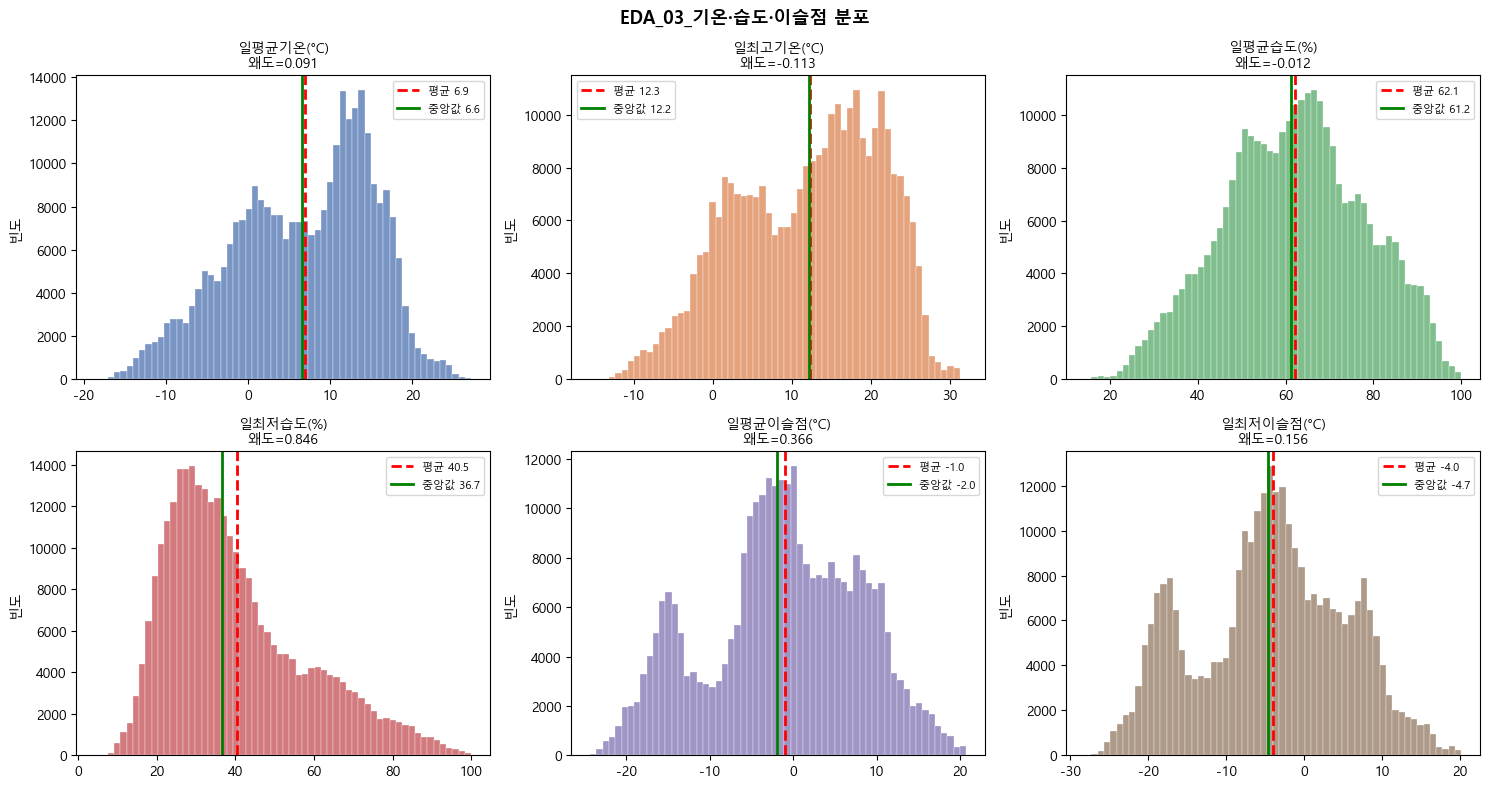

In [5]:
def plot_hist_group(cols, title, ncols=3):
    nrows = (len(cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten() if nrows > 1 else axes
    colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

    for i, col in enumerate(cols):
        ax = axes[i] if len(cols) > 1 else axes
        data = df_sample[col].dropna()
        a = stats_acc[col]
        mean   = a['sum'] / a['n']
        median = np.mean(a['medians'])
        skew   = np.mean(a['skews'])

        ax.hist(data, bins=60, color=colors[i % len(colors)], alpha=0.75,
                edgecolor='white', linewidth=0.3)
        ax.axvline(mean,   color='red',   linewidth=2, linestyle='--', label=f'평균 {mean:.1f}')
        ax.axvline(median, color='green', linewidth=2, linestyle='-',  label=f'중앙값 {median:.1f}')
        ax.set_title(f'{COL_LABEL[col]}\n왜도={skew:.3f}', fontsize=10)
        ax.legend(fontsize=8)
        ax.set_ylabel('빈도')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = title.replace(' ','_').replace('·','_') + '.png'
    plt.savefig(BASE_PATH + '\\' + fname, dpi=120, bbox_inches='tight')
    plt.show()

plot_hist_group(
    ['ta_mean','ta_max','hm_mean','hm_min','td_mean','td_min'],
    'EDA_03_기온·습도·이슬점 분포'
)

---
## Step 5. 히스토그램 — 풍속·강수량
 
> 풍속과 강수량은 **오른쪽으로 강하게 치우친** 분포가 예상됩니다.  
> - 대부분 날은 바람이 약하고 비도 안 오지만  
> - 가끔 강풍이 불거나 폭우가 쏟아지기 때문입니다.

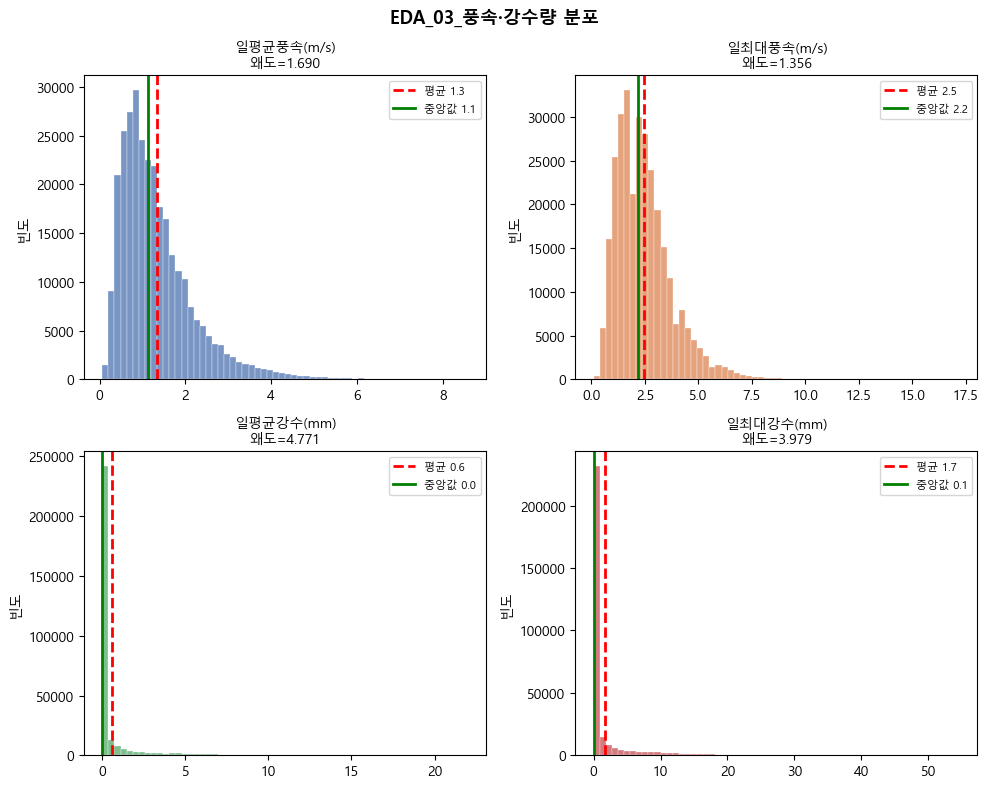

In [6]:
plot_hist_group(
    ['wind_ws_mean','wind_ws_max','rn_day_mean','rn_day_max'],
    'EDA_03_풍속·강수량 분포',
    ncols=2
)

---
## Step 6. 히스토그램 — 풍향 성분 (U/V/sin/cos)
 
> - U(동서방향), V(남북방향) 성분은 양수/음수 모두 존재합니다.  
> - 양수 U → 동쪽으로 부는 바람, 음수 U → 서쪽으로 부는 바람  
> - sin/cos는 -1~1 범위로 방향을 수치로 표현한 것입니다.

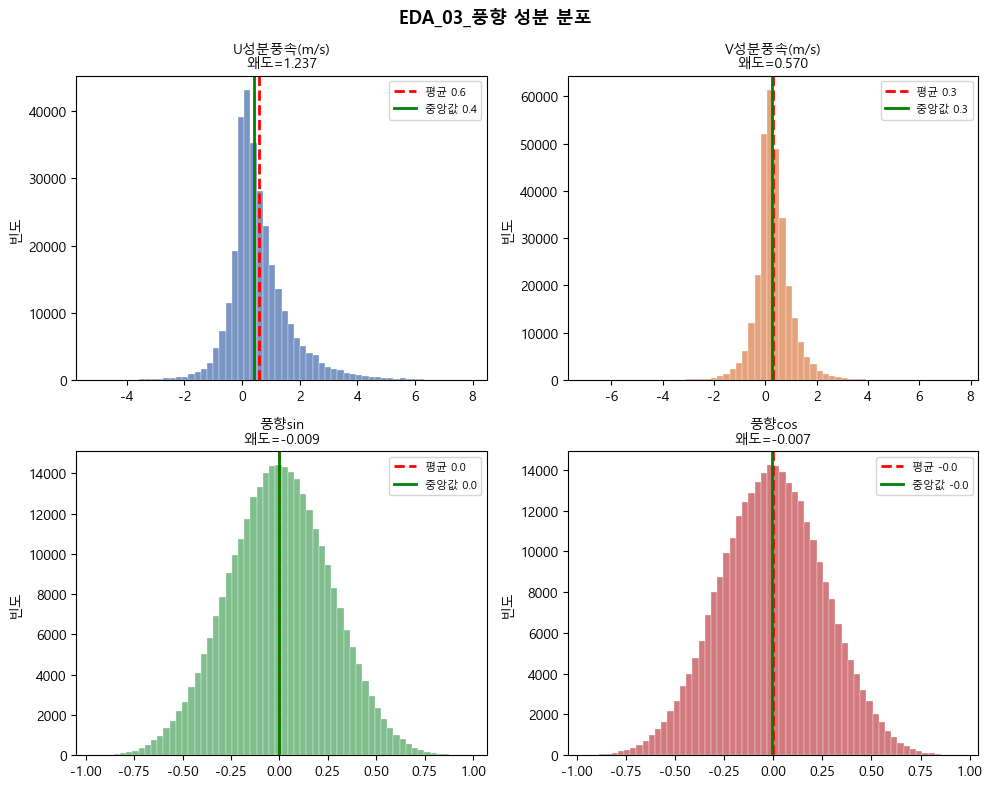

In [7]:
plot_hist_group(
    ['wind_uu_mean','wind_vv_mean','wind_wd_sin_mean','wind_wd_cos_mean'],
    'EDA_03_풍향 성분 분포',
    ncols=2
)

---
## Step 7. 월별 평균 추이 (계절성 확인)

> 2월(겨울) → 5월(초여름)로 갈수록 기온은 오르고, 습도는 어떻게 변하는지 확인합니다.  
> **계절성이 뚜렷하면** 나중에 산불 위험 예측 모델에서 **월/계절 변수가 중요**해집니다.

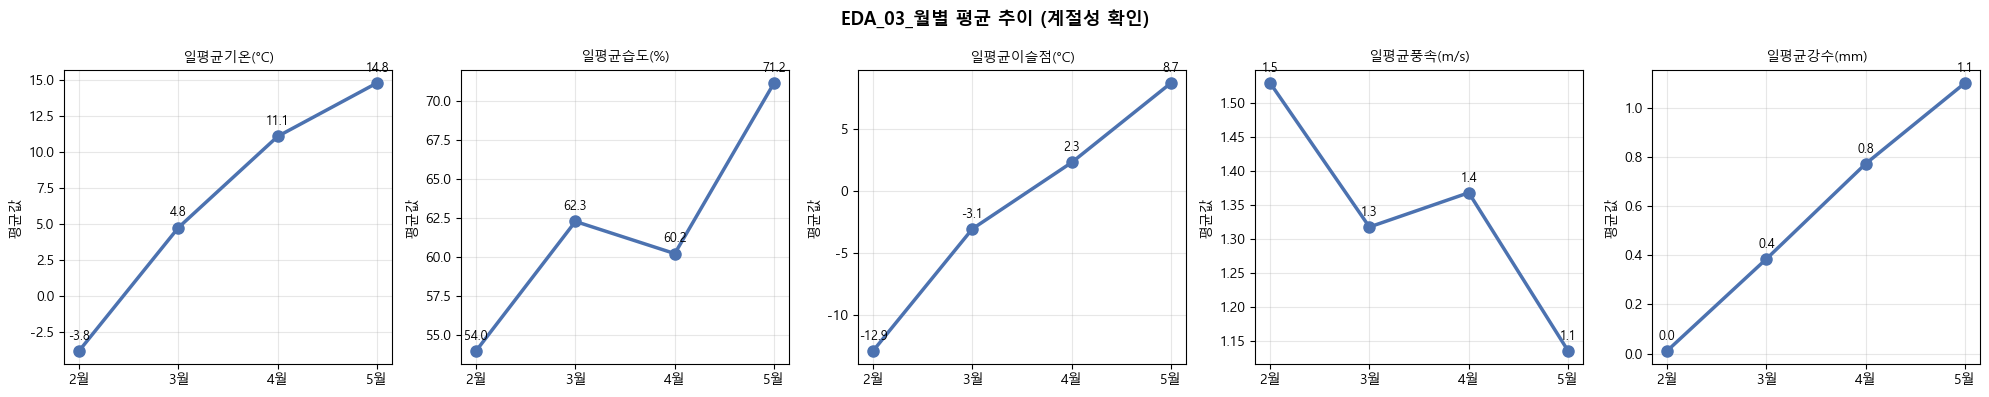

In [8]:
month_labels_short = ['2월', '3월', '4월', '5월']
target_cols = ['ta_mean', 'hm_mean', 'td_mean', 'wind_ws_mean', 'rn_day_mean']

fig, axes = plt.subplots(1, len(target_cols), figsize=(4*len(target_cols), 4))

for i, col in enumerate(target_cols):
    ax = axes[i]
    y_vals = [monthly_means[col][m] for m in MONTHS]
    ax.plot(month_labels_short, y_vals, marker='o', linewidth=2.5,
            color='#4C72B0', markersize=8)
    for j, v in enumerate(y_vals):
        ax.annotate(f'{v:.1f}', (month_labels_short[j], v),
                    textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
    ax.set_title(COL_LABEL[col], fontsize=10)
    ax.set_ylabel('평균값')
    ax.grid(True, alpha=0.3)

plt.suptitle('EDA_03_월별 평균 추이 (계절성 확인)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_PATH + '\\EDA_03_월별평균추이.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 8. 월별 기온 분포 비교 (박스플롯)
 
> 각 월의 기온 분포를 나란히 놓고 비교합니다.  
> 박스가 위로 올라갈수록 따뜻하고, 박스가 넓을수록 기온 변화폭이 큽니다.

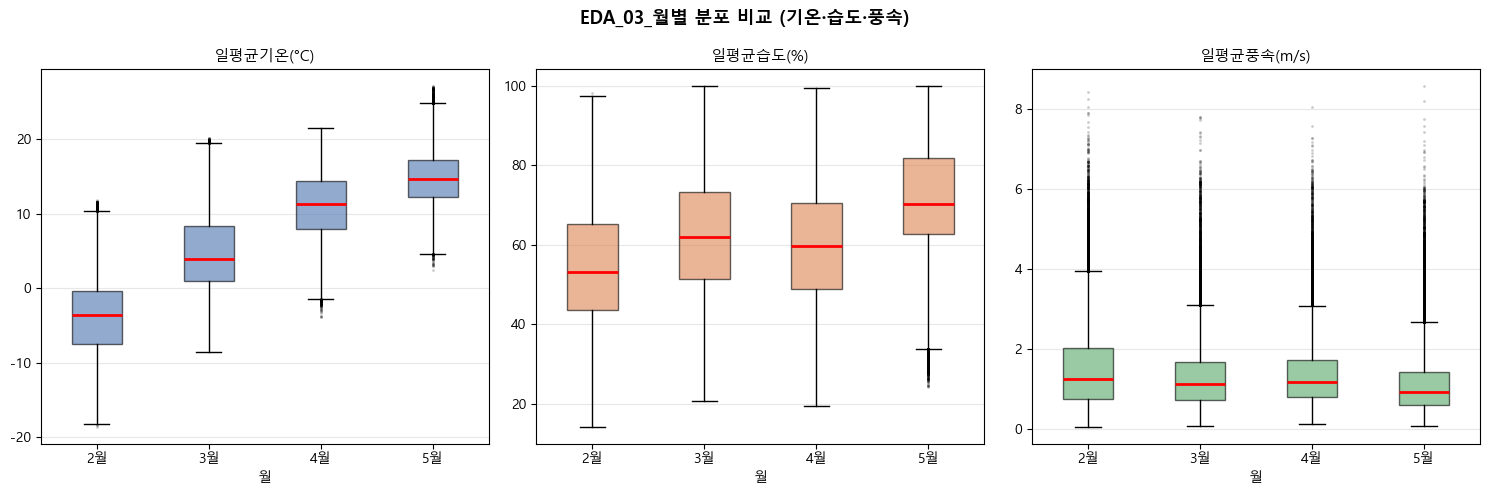

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
box_cols = ['ta_mean', 'hm_mean', 'wind_ws_mean']
box_colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, color in zip(axes, box_cols, box_colors):
    data_by_month = [
        df_sample[df_sample['month_label'] == MONTH_LABELS[m]][col].dropna().values
        for m in MONTHS
    ]
    bp = ax.boxplot(data_by_month, labels=month_labels_short,
                    patch_artist=True, notch=False,
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(COL_LABEL[col], fontsize=11)
    ax.set_xlabel('월')
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('EDA_03_월별 분포 비교 (기온·습도·풍속)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_PATH + '\\EDA_03_월별분포비교.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 9. 강수량 특별 분석 — 0값 비율과 극단값
  
> 강수량은 왜도가 **4.77**로 매우 높습니다.  
> 이유는 비가 오지 않는 날(0mm)이 대부분이기 때문입니다.  
> 왼쪽에 0값이 집중되고, 오른쪽 꼬리에 폭우 날들이 드물게 분포합니다.

=== 강수량 0값 비율 (비가 안 오는 격자-날짜 비율) ===
월                 rn_day_mean=0    rn_day_max=0
------------------------------------------------
2월(겨울)                    88.1%           88.1%
3월(초봄)                    59.9%           59.9%
4월(봄)                     61.4%           61.4%
5월(초여름)                   45.4%           45.4%


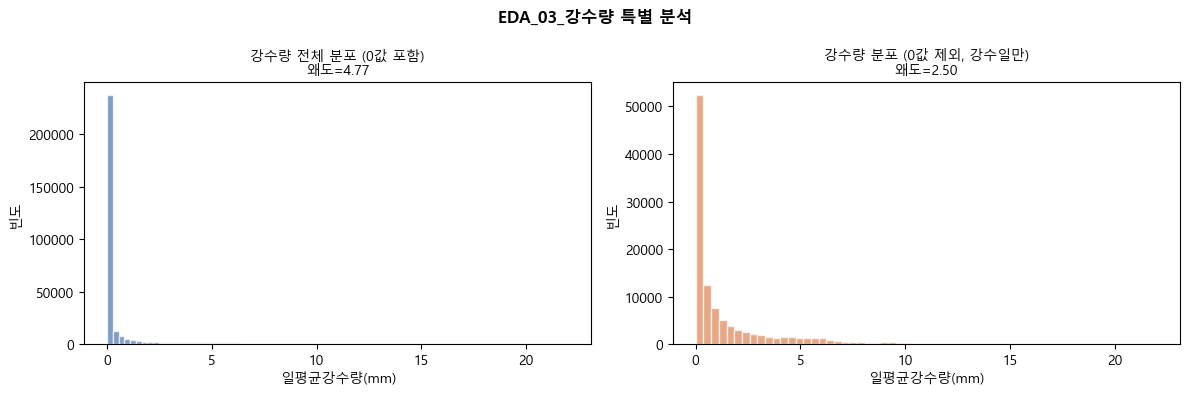

In [10]:
# 강수량 0값 비율 (전체 계산)
zero_ratio = {}
for m in MONTHS:
    df_tmp = pd.read_parquet(WEATHER_PATH, filters=[('month','==',m)],
                              columns=['rn_day_mean','rn_day_max'])
    zero_ratio[m] = {
        'rn_day_mean': float((df_tmp['rn_day_mean'] == 0).mean() * 100),
        'rn_day_max':  float((df_tmp['rn_day_max']  == 0).mean() * 100)
    }

print('=== 강수량 0값 비율 (비가 안 오는 격자-날짜 비율) ===')
print(f'{"월":<15} {"rn_day_mean=0":>15} {"rn_day_max=0":>15}')
print('-' * 48)
for m in MONTHS:
    print(f'{MONTH_LABELS[m]:<15} {zero_ratio[m]["rn_day_mean"]:>14.1f}% {zero_ratio[m]["rn_day_max"]:>14.1f}%')

# 0 제외한 강수 분포
rn_nonzero = df_sample[df_sample['rn_day_mean'] > 0]['rn_day_mean']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 전체 (0 포함)
axes[0].hist(df_sample['rn_day_mean'], bins=80, color='#4C72B0', alpha=0.7, edgecolor='white')
axes[0].set_title('강수량 전체 분포 (0값 포함)\n왜도=4.77', fontsize=10)
axes[0].set_xlabel('일평균강수량(mm)')
axes[0].set_ylabel('빈도')

# 0 제외
axes[1].hist(rn_nonzero, bins=60, color='#DD8452', alpha=0.7, edgecolor='white')
axes[1].set_title(f'강수량 분포 (0값 제외, 강수일만)\n왜도={rn_nonzero.skew():.2f}', fontsize=10)
axes[1].set_xlabel('일평균강수량(mm)')
axes[1].set_ylabel('빈도')

plt.suptitle('EDA_03_강수량 특별 분석', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_PATH + '\\EDA_03_강수량분포.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 10. 왜도 요약 및 해석

> **산불 예측 모델에서의 의미**:  
> 왜도가 큰 변수(강수량, 풍속)는 **로그 변환**을 해야 모델 성능이 좋아질 수 있습니다.  
> 특히 강수량은 로그 변환 후 정규분포에 가까워집니다.

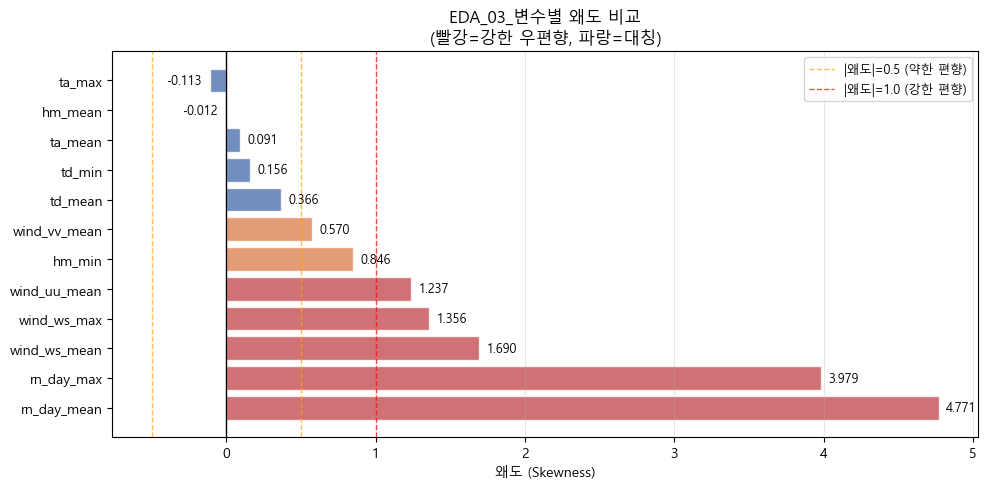


[왜도 기준 해석]
  |왜도| < 0.5  : 대칭 분포  → 그대로 사용
  0.5 ~ 1.0     : 중간 편향  → 필요시 sqrt 변환 고려
  > 1.0         : 강한 우편향 → 로그 변환 강력 권장

  로그 변환 권장 변수: ['wind_ws_mean', 'wind_ws_max', 'wind_uu_mean', 'rn_day_mean', 'rn_day_max']


In [11]:
# 왜도 막대그래프
skew_vals = {}
for col in SCALE10_COLS:
    skew_vals[col] = np.mean(stats_acc[col]['skews'])

skew_df = pd.DataFrame({'왜도': skew_vals}).sort_values('왜도', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#C44E52' if v > 1 else '#DD8452' if v > 0.5
              else '#4C72B0' if v > -0.5 else '#55A868'
              for v in skew_df['왜도']]
bars = ax.barh(skew_df.index, skew_df['왜도'], color=colors_bar, alpha=0.8, edgecolor='white')

for bar, val in zip(bars, skew_df['왜도']):
    ax.text(val + 0.05 if val >= 0 else val - 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

ax.axvline(0, color='black', linewidth=1)
ax.axvline(0.5,  color='orange', linewidth=1, linestyle='--', alpha=0.7, label='|왜도|=0.5 (약한 편향)')
ax.axvline(-0.5, color='orange', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(1.0,  color='red',    linewidth=1, linestyle='--', alpha=0.7, label='|왜도|=1.0 (강한 편향)')
ax.set_xlabel('왜도 (Skewness)')
ax.set_title('EDA_03_변수별 왜도 비교\n(빨강=강한 우편향, 파랑=대칭)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_PATH + '\\EDA_03_왜도비교.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n[왜도 기준 해석]')
print('  |왜도| < 0.5  : 대칭 분포  → 그대로 사용')
print('  0.5 ~ 1.0     : 중간 편향  → 필요시 sqrt 변환 고려')
print('  > 1.0         : 강한 우편향 → 로그 변환 강력 권장')
print()
high_skew = {k:v for k,v in skew_vals.items() if v > 1.0}
print(f'  로그 변환 권장 변수: {list(high_skew.keys())}')

---
## Step 11. 3단계 최종 요약

In [12]:
print('=' * 62)
print('  3단계 변수 분포 분석 최종 요약')
print('=' * 62)
print('''
[핵심 결과]

  기온 (ta_mean, ta_max)
  - 왜도 ≈ 0 : 좌우 대칭, 정규분포에 가까움
  - 2월 평균 → 5월 평균 : 뚜렷한 계절성 확인
  - 모델에서 별도 변환 불필요

  습도 (hm_mean, hm_min)
  - 왜도 ≈ 0~0.8 : 대체로 대칭, hm_min은 약간 우편향
  - 범위 0~100% 모두 채워짐 (건조한 날도 충분히 포함)

  이슬점 (td_mean, td_min)
  - 기온과 함께 움직이는 패턴 (계절성)

  풍속 (wind_ws_mean, wind_ws_max)
  - 왜도 1.3~1.7 : 강한 우편향
  - 대부분 약풍(1~2 m/s), 가끔 강풍 — 자연스러운 분포
  - 파생변수·모델 입력 시 log(1+x) 변환 권장

  강수량 (rn_day_mean, rn_day_max)
  - 왜도 4.0~4.8 : 매우 강한 우편향
  - 전체의 약 63%가 0mm (비 안 오는 날)
  - DWI(기상위험지수) 계산 시 3일 누적 강수량으로 변환 예정
  - 로그 변환 강력 권장

  풍향 sin/cos
  - 왜도 ≈ 0 : 완전 대칭 (원형 데이터 특성상 당연)
  - -1~1 범위 정상

[다음 단계 처리 사항]
  1. 강수량·풍속 → 파생변수 생성 시 log(1+x) 변환 적용
  2. 기온·이슬점·습도 → 그대로 사용 가능
  3. 계절성(월)을 feature로 추가 고려
''')
print('→ 다음: 4단계 변수 간 상관관계 분석')
print('=' * 62)

  3단계 변수 분포 분석 최종 요약

[핵심 결과]

  기온 (ta_mean, ta_max)
  - 왜도 ≈ 0 : 좌우 대칭, 정규분포에 가까움
  - 2월 평균 → 5월 평균 : 뚜렷한 계절성 확인
  - 모델에서 별도 변환 불필요

  습도 (hm_mean, hm_min)
  - 왜도 ≈ 0~0.8 : 대체로 대칭, hm_min은 약간 우편향
  - 범위 0~100% 모두 채워짐 (건조한 날도 충분히 포함)

  이슬점 (td_mean, td_min)
  - 기온과 함께 움직이는 패턴 (계절성)

  풍속 (wind_ws_mean, wind_ws_max)
  - 왜도 1.3~1.7 : 강한 우편향
  - 대부분 약풍(1~2 m/s), 가끔 강풍 — 자연스러운 분포
  - 파생변수·모델 입력 시 log(1+x) 변환 권장

  강수량 (rn_day_mean, rn_day_max)
  - 왜도 4.0~4.8 : 매우 강한 우편향
  - 전체의 약 63%가 0mm (비 안 오는 날)
  - DWI(기상위험지수) 계산 시 3일 누적 강수량으로 변환 예정
  - 로그 변환 강력 권장

  풍향 sin/cos
  - 왜도 ≈ 0 : 완전 대칭 (원형 데이터 특성상 당연)
  - -1~1 범위 정상

[다음 단계 처리 사항]
  1. 강수량·풍속 → 파생변수 생성 시 log(1+x) 변환 적용
  2. 기온·이슬점·습도 → 그대로 사용 가능
  3. 계절성(월)을 feature로 추가 고려

→ 다음: 4단계 변수 간 상관관계 분석
